# Preliminary data processing

This script takes in the results from assembles-datasets and creates certain userful variables in the data.

In [1]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

import matplotlib as mpl
import matplotlib.ticker as ticker

import numpy as np
import pandas as pd
import os
import plotly.graph_objects as go
import plotly.express as px
import pickle

# import clustering packages
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
import seaborn as sns

plt.style.use('custom.mplstyle')
%config InlineBackend.figure_format = 'retina'
from tqdm import tqdm

from stoch_sim_model import *

## 0. Load data and build datasets

In [2]:
# Load data from infections
reg_model = ''
runs = '-5-'
comment = "acute_all-sparse-reg"

d_mean = '/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/raw/stacked_data'+runs+'runs'+'-'+comment+'.pkl'
mean_df = pd.read_pickle(d_mean)

with pd.option_context('display.max_columns', None):
    display(mean_df)

,psi_Na_I,psi_Na_HI,psi_Na_HE,L0_Na,psi_NE_I,psi_NE_HI,psi_NE_HE,L0_NE,psi_EM_I,psi_EM_HI,psi_EM_HE,L0_EM,psi_EE_I,psi_EE_HI,psi_EE_HE,L0_EE,d_I,K_I,b_I,K_H,N_0,S_0,I_0,d_S,d_IE,b_H,d_H,max_Na,b_myc,d_myc,myc_thresh,t_bind,t_unbind,t_Na_div,t_E_div,t_M_div,t_E_die,t_act,p_load,T_max_pI,T_min_pI,harm_pI,harm_pS,max_pE,T_pE_max,T_pE_start,max_eM,T_eM_min,max_cM,T_cM_min,int_pHE,int_pHI,min_pS
0,-2.0,-2.0,-2.0,-7.0,0.0,0.0,0.0,-7.0,0.0,0.0,0.0,-7.0,0.0,0.0,0.0,-7.0,0.01,100000.000000,1.000000e-01,50000.0,100.000000,10000000.0,1000000.0,0.01,16.0,1.0,2.0,4.0,4.0,0.25,1.0,1.0,0.75,0.25,0.333333,0.5,2.5,0.25,5.513184e+07,20.0000,0.0,5.303137e+06,0.000000,198.0,20.0000,20.0,0.0,0.000000,0.0,0.0,0.000000,158536.199681,6.027997e+06
1,-2.0,-2.0,-2.0,-7.0,0.0,0.0,0.0,-7.0,0.0,0.0,0.0,-7.0,0.0,0.0,0.0,-7.0,0.01,100000.000000,1.000000e-01,50000.0,234.034732,10000000.0,1000000.0,0.01,16.0,1.0,2.0,4.0,4.0,0.25,1.0,1.0,0.75,0.25,0.333333,0.5,2.5,0.25,5.513184e+07,20.0000,0.0,5.303137e+06,0.000000,468.0,20.0000,20.0,0.0,0.000000,0.0,0.0,0.000000,158536.199681,6.027997e+06
2,-2.0,-2.0,-2.0,-7.0,0.0,0.0,0.0,-7.0,0.0,0.0,0.0,-7.0,0.0,0.0,0.0,-7.0,0.01,100000.000000,1.000000e-01,50000.0,547.722558,10000000.0,1000000.0,0.01,16.0,1.0,2.0,4.0,4.0,0.25,1.0,1.0,0.75,0.25,0.333333,0.5,2.5,0.25,5.513184e+07,20.0000,0.0,5.303137e+06,0.000000,1094.0,20.0000,20.0,0.0,0.000000,0.0,0.0,0.000000,158536.199681,6.027997e+06
3,-2.0,-2.0,-2.0,-7.0,0.0,0.0,0.0,-7.0,0.0,0.0,0.0,-7.0,0.0,0.0,0.0,-7.0,0.01,100000.000000,1.000000e-01,50000.0,1281.861019,10000000.0,1000000.0,0.01,16.0,1.0,2.0,4.0,4.0,0.25,1.0,1.0,0.75,0.25,0.333333,0.5,2.5,0.25,5.513184e+07,20.0000,0.0,5.303137e+06,0.000000,2562.0,20.0000,20.0,0.0,0.000000,0.0,0.0,0.000000,158536.199681,6.027997e+06
4,-2.0,-2.0,-2.0,-7.0,0.0,0.0,0.0,-7.0,0.0,0.0,0.0,-7.0,0.0,0.0,0.0,-7.0,0.01,100000.000000,1.000000e-01,50000.0,3000.000000,10000000.0,1000000.0,0.01,16.0,1.0,2.0,4.0,4.0,0.25,1.0,1.0,0.75,0.25,0.333333,0.5,2.5,0.25,5.513184e+07,20.0000,0.0,5.303137e+06,0.000000,6000.0,20.0000,20.0,0.0,0.000000,0.0,0.0,0.000000,158536.199681,6.027997e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40352385,2.0,2.0,2.0,7.0,0.0,0.0,0.0,7.0,0.0,0.0,0.0,7.0,0.0,0.0,0.0,7.0,1.00,129154.966501,1.500000e-07,50000.0,1000.000000,10000000.0,1000.0,0.01,16.0,1.0,2.0,4.0,4.0,0.25,1.0,1.0,0.75,0.25,0.333333,0.5,2.5,0.25,4.752619e+06,16.4256,0.0,5.155629e+06,2119.598000,6359.6,8.5568,20.0,21145.6,4.617110,13216.4,5.0,828.692345,316910.722015,5.104182e+06
40352386,2.0,2.0,2.0,7.0,0.0,0.0,0.0,7.0,0.0,0.0,0.0,7.0,0.0,0.0,0.0,7.0,1.00,215443.469003,1.500000e-07,50000.0,1000.000000,10000000.0,1000.0,0.01,16.0,1.0,2.0,4.0,4.0,0.25,1.0,1.0,0.75,0.25,0.333333,0.5,2.5,0.25,4.792578e+06,16.3328,0.0,5.185980e+06,2085.359722,6344.2,10.2112,20.0,23131.0,4.643719,15262.0,5.0,727.419195,317739.024675,5.077936e+06
40352387,2.0,2.0,2.0,7.0,0.0,0.0,0.0,7.0,0.0,0.0,0.0,7.0,0.0,0.0,0.0,7.0,1.00,359381.366380,1.500000e-07,50000.0,1000.000000,10000000.0,1000.0,0.01,16.0,1.0,2.0,4.0,4.0,0.25,1.0,1.0,0.75,0.25,0.333333,0.5,2.5,0.25,4.820507e+06,16.2720,0.0,5.207054e+06,2058.399421,6239.2,10.1248,20.0,18350.6,4.569321,10562.4,5.0,566.799602,318497.460846,5.059611e+06
40352388,2.0,2.0,2.0,7.0,0.0,0.0,0.0,7.0,0.0,0.0,0.0,7.0,0.0,0.0,0.0,7.0,1.00,599484.250319,1.500000e-07,50000.0,1000.000000,10000000.0,1000.0,0.01,16.0,1.0,2.0,4.0,4.0,0.25,1.0,1.0,0.75,0.25,0.333333,0.5,2.5,0.25,4.839547e+06,16.2304,0.0,5.221362e+06,2047.637716,6270.6,9.8768,20.0,20639.2,4.608674,12873.4,5.0,456.259252,319130.487699,5.047123e+06


## 1. Understanding the statistics of responses to an infection

In [3]:
# Create additional variables
virs = np.unique(mean_df[['I_0','d_I','K_I','b_I','K_H','N_0']].to_numpy(), axis = 0)

mean_df['antigenicity_over_harm'] = antigenicity_over_harm(mean_df)
mean_df['T_pE_clear'] = mean_df['T_pE_max'] - mean_df['T_max_pI']
mean_df['max_eM_fold'] = np.log10(1 + mean_df['max_eM']/mean_df['N_0'])
mean_df['max_cM_fold'] = np.log10(1 + mean_df['max_cM']/mean_df['N_0'])
mean_df['stim_pI'] = np.log10(1 + (mean_df['p_load']/mean_df['K_I'])/sim_duration)
mean_df['stim_pHI'] = np.log10(1 + (mean_df['int_pHI']/mean_df['K_H']))
mean_df['stim_pHE'] = np.log10(1 + (mean_df['int_pHE']/mean_df['K_H']))
mean_df['max_pE_fold'] = np.log10(1 + mean_df['max_pE']/mean_df['N_0'])
mean_df['log_min_pS'] = np.log10(mean_df['min_pS']/mean_df['S_0'])

# identify Biologically evidenced networks
keep_vars = ['harm_pI', 'harm_pS', 'max_eM_fold', 'max_cM_fold', 'T_eM_min',
             'T_min_pI', 'T_max_pI', 'T_pE_start', 'T_pE_clear',
             'stim_pI', 'stim_pHI', 'stim_pHE',
             'log_min_pS', 'antigenicity_over_harm']

In [4]:
# save data sets
infection_scenarios = []
no_eff_data = [[] for i in np.arange(len(virs))]
b_S = d_S*S_0

for l, (I_0, d_I, K_I, b_I, K_H, N_0) in enumerate(tqdm(virs)):
    data = mean_df.loc[(mean_df["d_I"] == d_I)*(mean_df["K_I"] == K_I)*(mean_df["b_I"] == b_I)*(mean_df["K_H"] == K_H)*(mean_df["N_0"] == N_0)*(mean_df["I_0"] == I_0), 
    ['b_I','d_I', 'K_I', 'I_0','S_0', 'N_0', 'd_S', 'K_H'] + Na_reg + NE_reg + EM_reg + EE_reg + keep_vars]

    # compute infection harm without T cell response
    no_eff_data[l] = lin_stoch_sim(N_0 = 0, I_0 = I_0, K_I = K_I, d_I = d_I, b_I = b_I,
                                   infection_model = "cancer" if b_I >= b_C else "acute")
    no_eff_stats = no_eff_data[l]["summary_stats"]

    data.loc[:,"harm_pI_noprotection"] = no_eff_stats[3]/(b_S*sim_duration)
    data.loc[:,"peff_clearance"] = (no_eff_stats[3] - data['harm_pI'].to_numpy())/(b_S*sim_duration)
    data.loc[:,"peff_toxicity"] = data['harm_pS'].to_numpy()/(b_S*sim_duration)

    infection_scenarios.append(data)

# stack datasets
clustered_mean_df = pd.concat(infection_scenarios)
clustered_mean_df.to_pickle('/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/processed_data'+runs+'runs'+'-'+comment+'.pkl')

with open('/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/list_processed_data'+runs+'runs'+'-'+comment+'.pkl', 'wb') as f:
    pickle.dump(infection_scenarios, f)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 130/130 [04:48<00:00,  2.22s/it]


In [5]:
del clustered_mean_df, infection_scenarios

,b_I,d_I,K_I,I_0,S_0,N_0,d_S,K_H,psi_Na_I,psi_Na_HI,psi_Na_HE,L0_Na,psi_NE_I,psi_NE_HI,psi_NE_HE,L0_NE,psi_EM_I,psi_EM_HI,psi_EM_HE,L0_EM,psi_EE_I,psi_EE_HI,psi_EE_HE,L0_EE,harm_pI,harm_pS,max_eM_fold,max_cM_fold,T_eM_min,T_min_pI,T_max_pI,T_pE_start,T_pE_clear,stim_pI,stim_pHI,stim_pHE,log_min_pS,antigenicity_over_harm,harm_pI_noprotection,peff_clearance,peff_toxicity
20,0.0,0.01,100000000.0,0.0,10000000.0,100.0,0.01,50000.0,-2.0,-2.0,-2.0,-7.0,0.0,0.0,0.0,-7.0,0.0,0.0,0.0,-7.0,0.0,0.0,0.0,-7.0,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.0,0.0,20.0,20.0000,0.040968,0.312371,0.000000,-0.005405,NaN,0.000000,0.000000,0.000000
150,0.0,0.01,100000000.0,0.0,10000000.0,100.0,0.01,50000.0,-2.0,-2.0,-2.0,-7.0,0.0,0.0,0.0,-7.0,0.0,0.0,0.0,-7.0,0.0,0.0,0.0,-3.5,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.0,0.0,20.0,20.0000,0.040968,0.312371,0.000000,-0.005405,NaN,0.000000,0.000000,0.000000
280,0.0,0.01,100000000.0,0.0,10000000.0,100.0,0.01,50000.0,-2.0,-2.0,-2.0,-7.0,0.0,0.0,0.0,-7.0,0.0,0.0,0.0,-7.0,0.0,0.0,0.0,0.0,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.0,0.0,20.0,20.0000,0.040968,0.312371,0.000000,-0.005405,NaN,0.000000,0.000000,0.000000
410,0.0,0.01,100000000.0,0.0,10000000.0,100.0,0.01,50000.0,-2.0,-2.0,-2.0,-7.0,0.0,0.0,0.0,-7.0,0.0,0.0,0.0,-7.0,0.0,0.0,0.0,3.5,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.0,0.0,20.0,20.0000,0.040968,0.312371,0.000000,-0.005405,NaN,0.000000,0.000000,0.000000
540,0.0,0.01,100000000.0,0.0,10000000.0,100.0,0.01,50000.0,-2.0,-2.0,-2.0,-7.0,0.0,0.0,0.0,-7.0,0.0,0.0,0.0,-7.0,0.0,0.0,0.0,7.0,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.0,0.0,20.0,20.0000,0.040968,0.312371,0.000000,-0.005405,NaN,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40351769,0.1,0.01,100000000.0,1000000.0,10000000.0,3000.0,0.01,50000.0,2.0,2.0,2.0,7.0,0.0,0.0,0.0,7.0,0.0,0.0,0.0,7.0,0.0,0.0,0.0,-7.0,5.301710e+06,4785.274568,1.033029,0.699693,4.443421,0.0,20.0,20.0,-16.5584,0.011805,0.620124,0.003393,-0.219734,3.349485,2.651379,0.000524,0.002393
40351899,0.1,0.01,100000000.0,1000000.0,10000000.0,3000.0,0.01,50000.0,2.0,2.0,2.0,7.0,0.0,0.0,0.0,7.0,0.0,0.0,0.0,7.0,0.0,0.0,0.0,-3.5,5.301713e+06,4774.147852,1.051387,0.738442,4.468303,0.0,20.0,20.0,-16.0096,0.011805,0.620124,0.003484,-0.219734,3.349485,2.651379,0.000522,0.002387
40352029,0.1,0.01,100000000.0,1000000.0,10000000.0,3000.0,0.01,50000.0,2.0,2.0,2.0,7.0,0.0,0.0,0.0,7.0,0.0,0.0,0.0,7.0,0.0,0.0,0.0,0.0,5.301527e+06,5335.602998,1.127647,0.828561,4.480013,0.0,20.0,20.0,-16.2128,0.011804,0.620117,0.004141,-0.219722,3.349485,2.651379,0.000615,0.002668
40352159,0.1,0.01,100000000.0,1000000.0,10000000.0,3000.0,0.01,50000.0,2.0,2.0,2.0,7.0,0.0,0.0,0.0,7.0,0.0,0.0,0.0,7.0,0.0,0.0,0.0,3.5,5.301358e+06,5848.705172,1.211327,0.943752,4.515282,0.0,20.0,20.0,-16.0560,0.011803,0.620110,0.004882,-0.219711,3.349485,2.651379,0.000699,0.002924


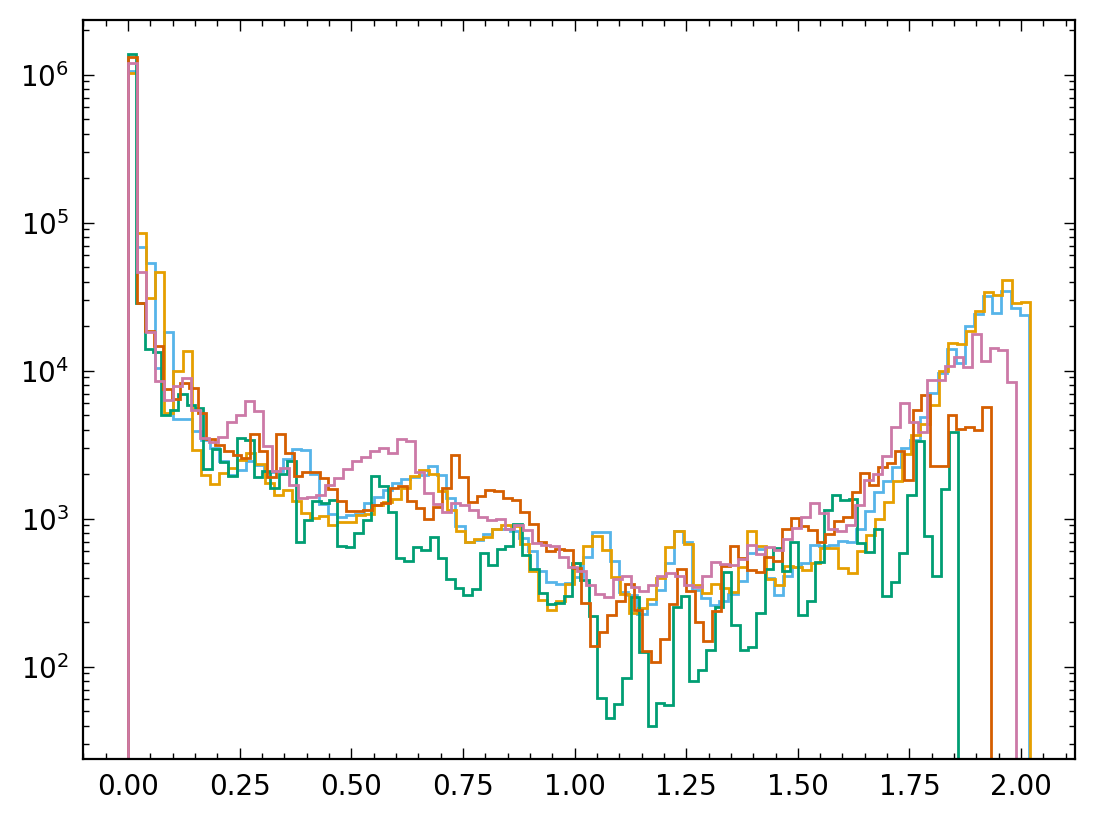

,antigenicity_over_harm,stim_pI,stim_pHI,stim_pHE
0,-26.795884,0.771028,0.620211,2.157685
1,-6.698971,1.455880,0.620211,2.175863
2,0.700124,0.094770,0.870528,1.641856
3,0.717337,0.126712,0.961914,1.633700
4,0.735609,0.156575,1.037099,1.612346
...,...,...,...,...
100,2.677607,2.185883,1.194333,1.638715
101,2.813581,2.306246,1.154156,1.706882
102,3.349485,0.011811,0.620211,2.048877
103,5.359177,0.062592,0.620211,2.059304


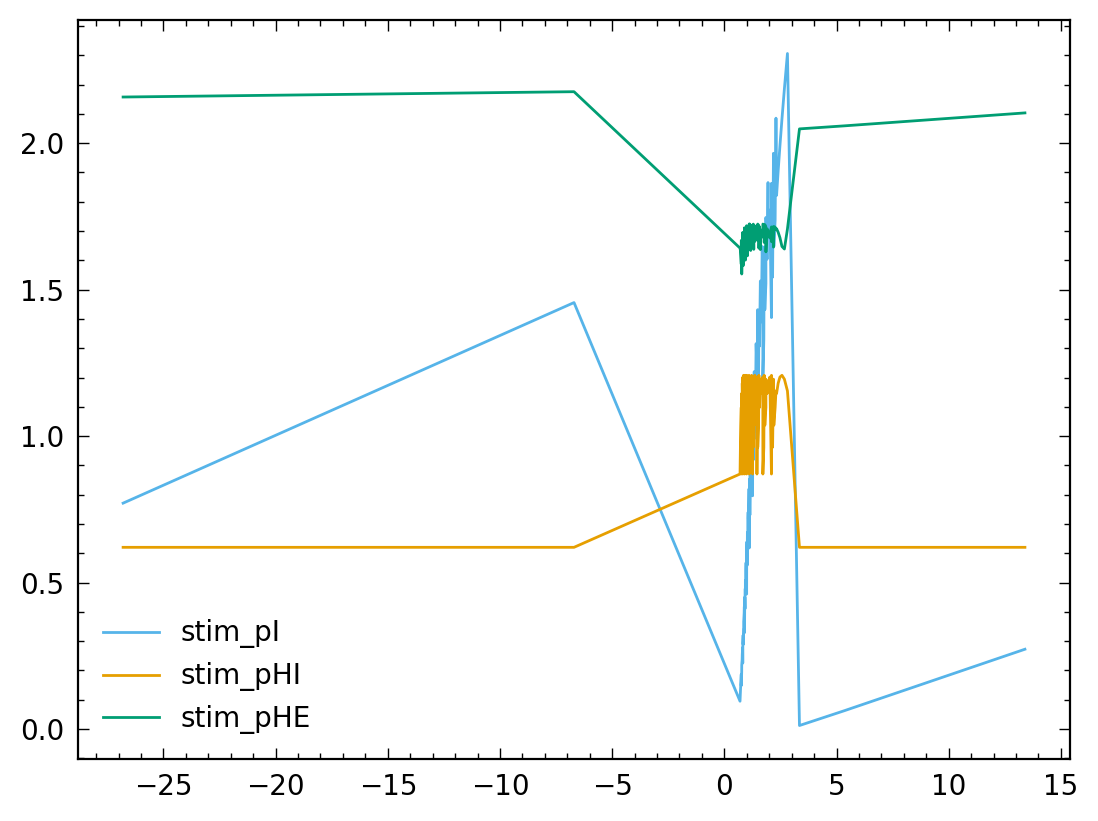

fevals: 1050
fevals: 950
fevals: 24
fevals: 380


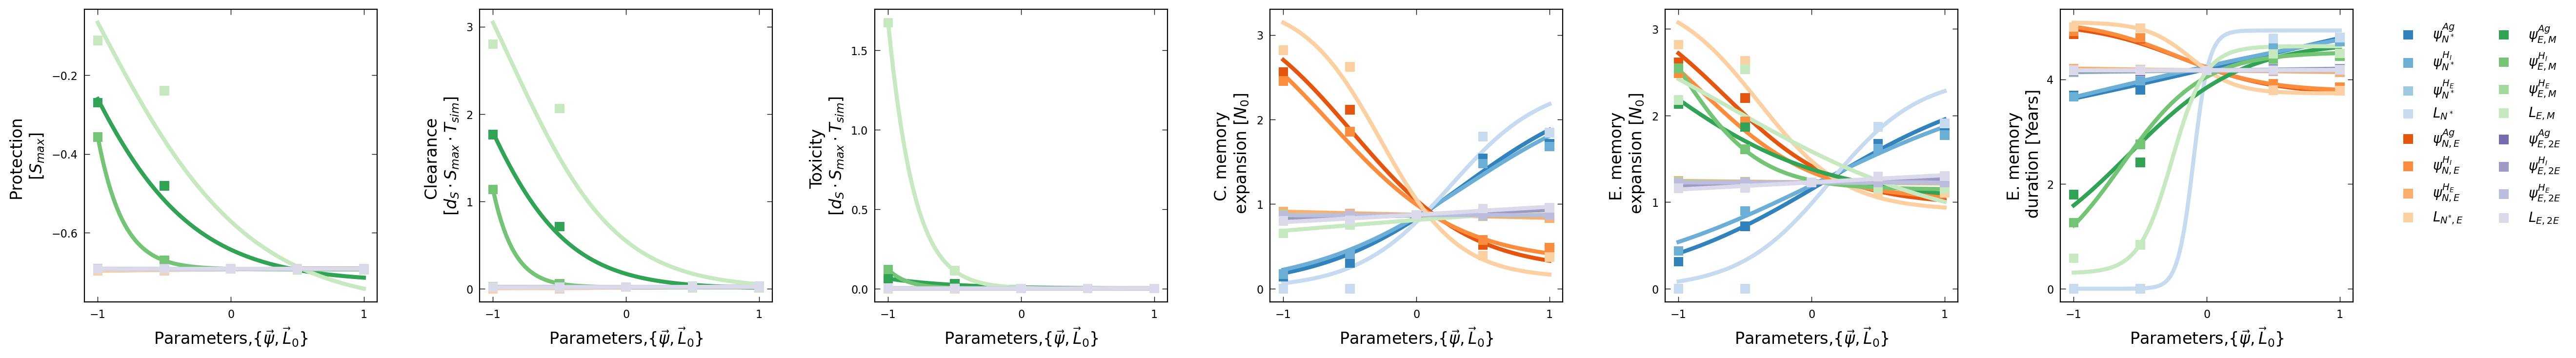

fevals: 12
fevals: 39
fevals: 14
fevals: 11
fevals: 10
fevals: 15
fevals: 26
fevals: 15
fevals: 40
fevals: 19
fevals: 27
fevals: 11
fevals: 14
fevals: 18
fevals: 27
fevals: 8


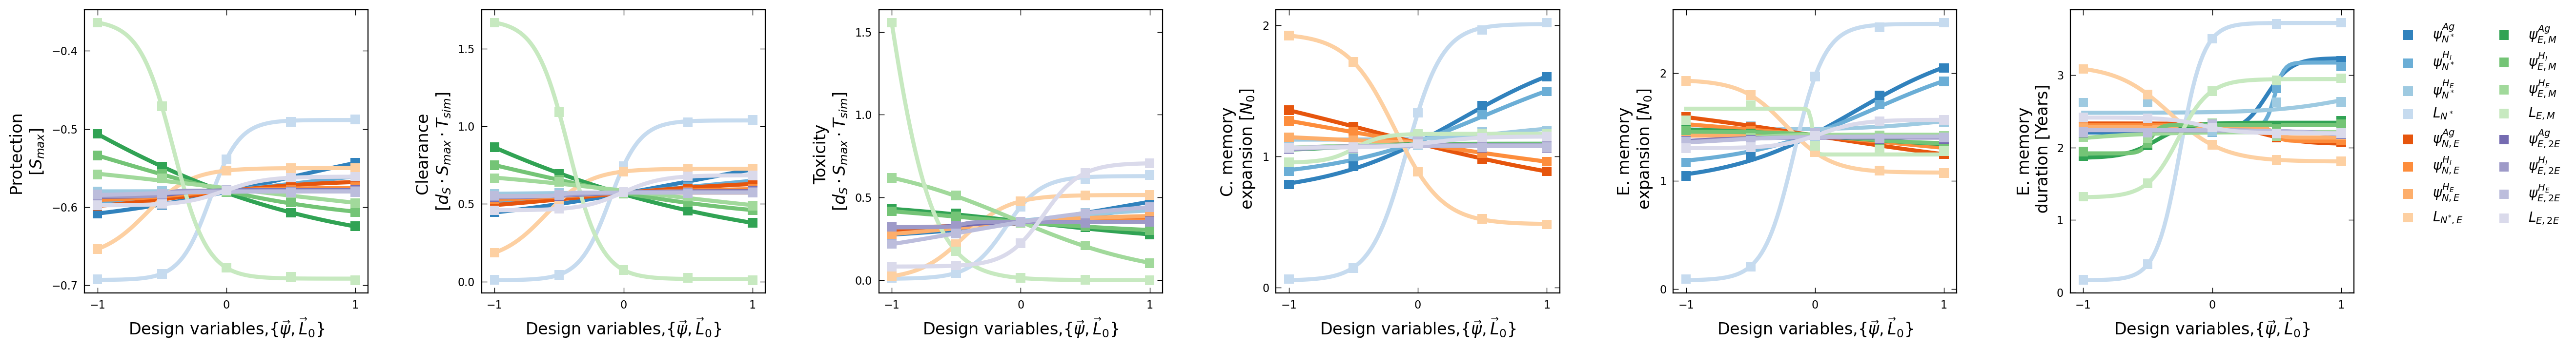

,y_range,y_min,psi_Na_I,psi_Na_HI,psi_Na_HE,L0_Na,psi_NE_I,psi_NE_HI,psi_NE_HE,L0_NE,psi_EM_I,psi_EM_HI,psi_EM_HE,L0_EM,psi_EE_I,psi_EE_HI,psi_EE_HE,L0_EE,intercept_Na,intercept_NE,intercept_EM,intercept_EE,sigma_y_max,sigma_y_min,sigma_psi_Na_I,sigma_psi_Na_HI,sigma_psi_Na_HE,sigma_L0_Na,sigma_psi_NE_I,sigma_psi_NE_HI,sigma_psi_NE_HE,sigma_L0_NE,sigma_psi_EM_I,sigma_psi_EM_HI,sigma_psi_EM_HE,sigma_L0_EM,sigma_psi_EE_I,sigma_psi_EE_HI,sigma_psi_EE_HE,sigma_L0_EE,sigma_intercept_Na,sigma_intercept_NE,sigma_intercept_EM,sigma_intercept_EE,d_I,K_I,b_I,K_H,N_0,S_0,I_0,mean_perf,max_perf,min_perf,median_perf,perf_index,rmse,y_std,harm_pI_noprotection,stim_pI,stim_pHI,stim_pHE,antigenicity_over_harm
0,0.000683,-0.006005,-0.001464,-0.010053,-0.001957,-0.059548,0.043177,0.006510,-0.004176,-0.048038,0.012226,0.005658,0.117515,1.276183,-0.032776,-0.010938,-0.037636,-0.148097,2.902149,3.054262,11.235107,3.752368,0.000102,1.019781e-04,0.004904,0.004995,0.004905,0.006186,0.009129,0.005863,0.005806,0.008360,0.007116,0.007113,0.007404,0.121718,0.008024,0.007978,0.008033,0.005707,0.199123,0.250729,0.866344,0.174487,0.01,100000000.0,0.0,50000.0,100.000000,10000000.0,0.0,-0.005417,-0.005405,-0.006087,-0.005405,0.0,0.000063,0.000069,0.000000,0.040966,0.312424,0.040534,NaN
6,0.001961,-0.007103,-0.000917,-0.005316,-0.001925,-0.059427,0.023396,-0.005437,-0.003246,-0.052097,0.010631,0.005065,0.155898,1.268068,-0.023810,-0.011862,-0.056206,-0.142001,2.845410,2.997189,10.939222,3.496584,0.000234,2.338194e-04,0.005363,0.005391,0.005366,0.006737,0.007253,0.006321,0.006284,0.008706,0.006701,0.006699,0.007300,0.106382,0.007477,0.007452,0.007593,0.005363,0.182405,0.226640,0.754577,0.143040,0.01,100000000.0,0.0,50000.0,234.034732,10000000.0,0.0,-0.005447,-0.005405,-0.007365,-0.005405,0.0,0.000206,0.000228,0.000000,0.040964,0.312424,0.061358,NaN
12,0.004901,-0.009613,-0.000771,-0.003390,-0.002656,-0.060660,0.017759,-0.006985,-0.003341,-0.054007,0.009657,0.005617,0.194771,0.983289,-0.020538,-0.011170,-0.080891,-0.133941,2.805032,2.989989,8.837587,3.343684,0.000517,5.163129e-04,0.005405,0.005415,0.005411,0.006662,0.007038,0.006589,0.006523,0.008789,0.006388,0.006386,0.007390,0.037339,0.007020,0.006999,0.007339,0.005103,0.169803,0.215091,0.280141,0.128756,0.01,100000000.0,0.0,50000.0,547.722558,10000000.0,0.0,-0.005519,-0.005405,-0.010305,-0.005405,0.0,0.000534,0.000595,0.000000,0.040959,0.312424,0.088222,NaN
18,0.011515,-0.015214,-0.000842,-0.003127,-0.003772,-0.061644,0.015901,-0.007807,-0.004384,-0.055060,0.009563,0.006979,0.233572,0.771869,-0.018608,-0.011283,-0.109080,-0.129234,2.766751,2.964502,7.313843,3.247608,0.001128,1.124975e-03,0.005361,0.005368,0.005372,0.006513,0.006926,0.006623,0.006555,0.008673,0.006257,0.006256,0.007707,0.018257,0.006700,0.006683,0.007335,0.004895,0.161352,0.206467,0.157235,0.120880,0.01,100000000.0,0.0,50000.0,1281.861019,10000000.0,0.0,-0.005687,-0.005405,-0.016919,-0.005405,0.0,0.001279,0.001431,0.000000,0.040948,0.312424,0.122296,NaN
24,0.025837,-0.027241,-0.000621,-0.002322,-0.004698,-0.061512,0.014955,-0.008371,-0.006046,-0.055456,0.009290,0.008437,0.269774,0.641406,-0.017277,-0.011279,-0.134705,-0.124015,2.722118,2.941890,6.378036,3.162070,0.002392,2.385164e-03,0.005247,0.005251,0.005265,0.006384,0.006853,0.006617,0.006565,0.008595,0.006145,0.006145,0.008061,0.012206,0.006398,0.006383,0.007433,0.004698,0.156315,0.201545,0.121520,0.115430,0.01,100000000.0,0.0,50000.0,3000.000000,10000000.0,0.0,-0.006063,-0.005405,-0.031241,-0.005405,0.0,0.002899,0.003248,0.000000,0.040923,0.312424,0.164333,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
750,0.034615,-0.219827,0.237686,1.875786,0.362192,2.082690,0.099025,0.848592,0.252233,0.956603,-0.194566,-2.120343,-0.925033,-2.136910,0.117698,1.172725,0.520134,1.214558,1.123761,

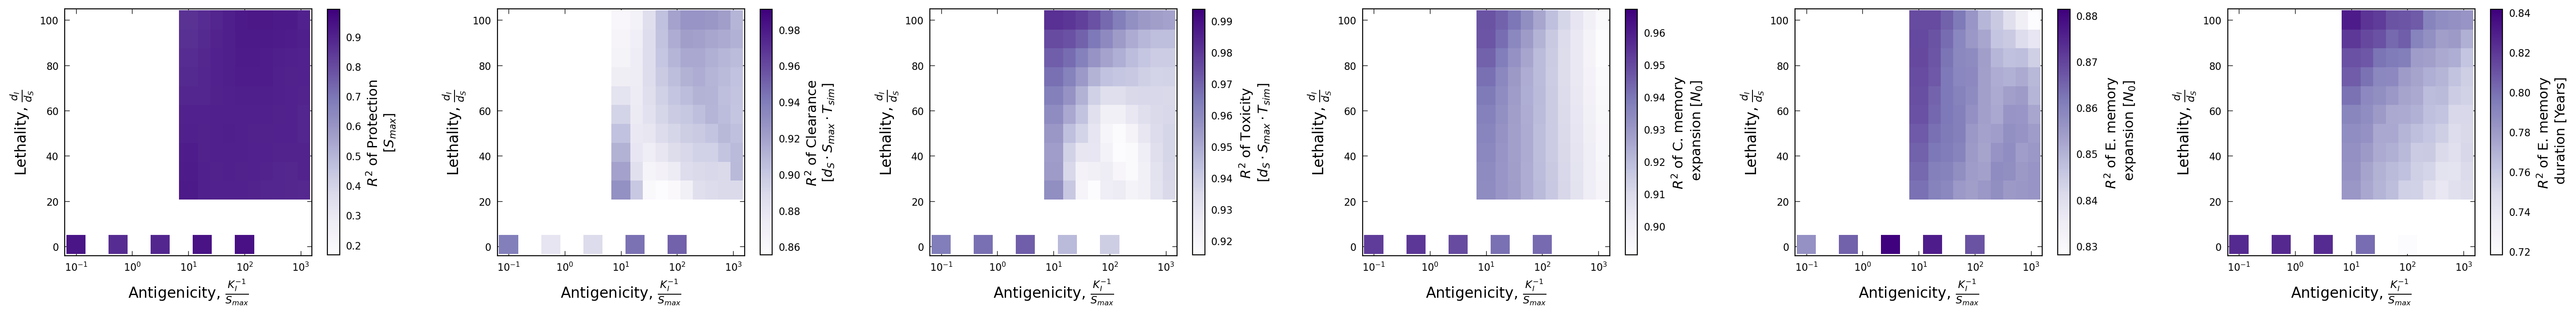

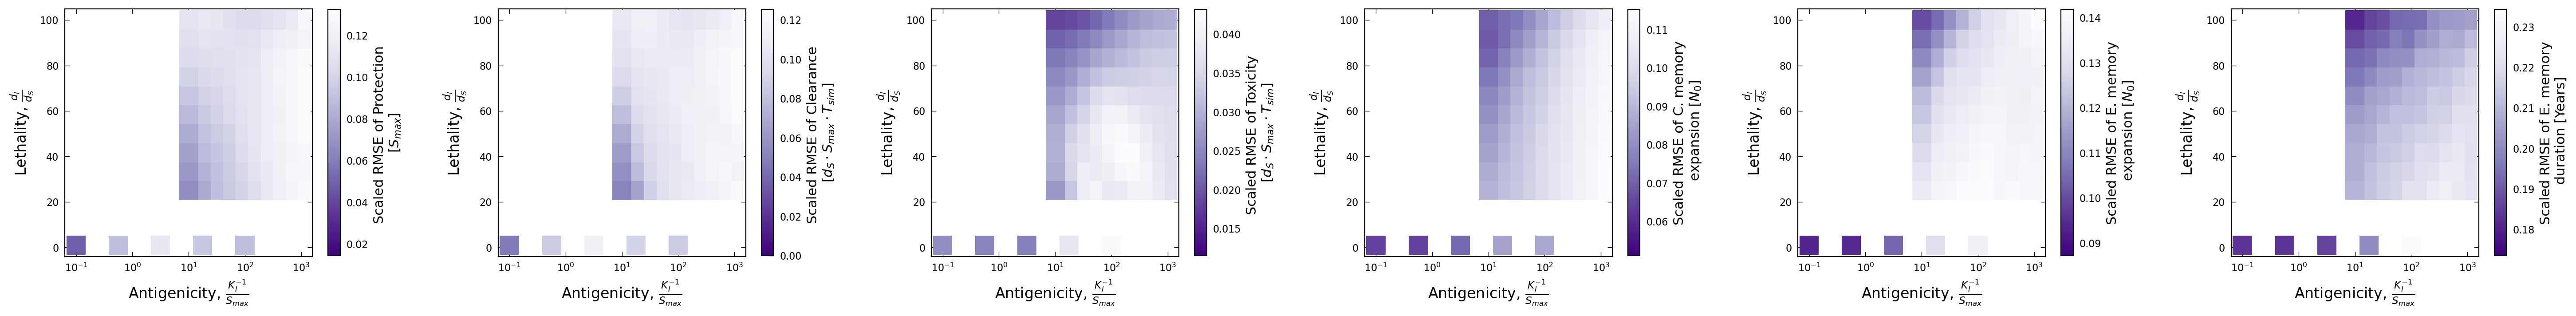

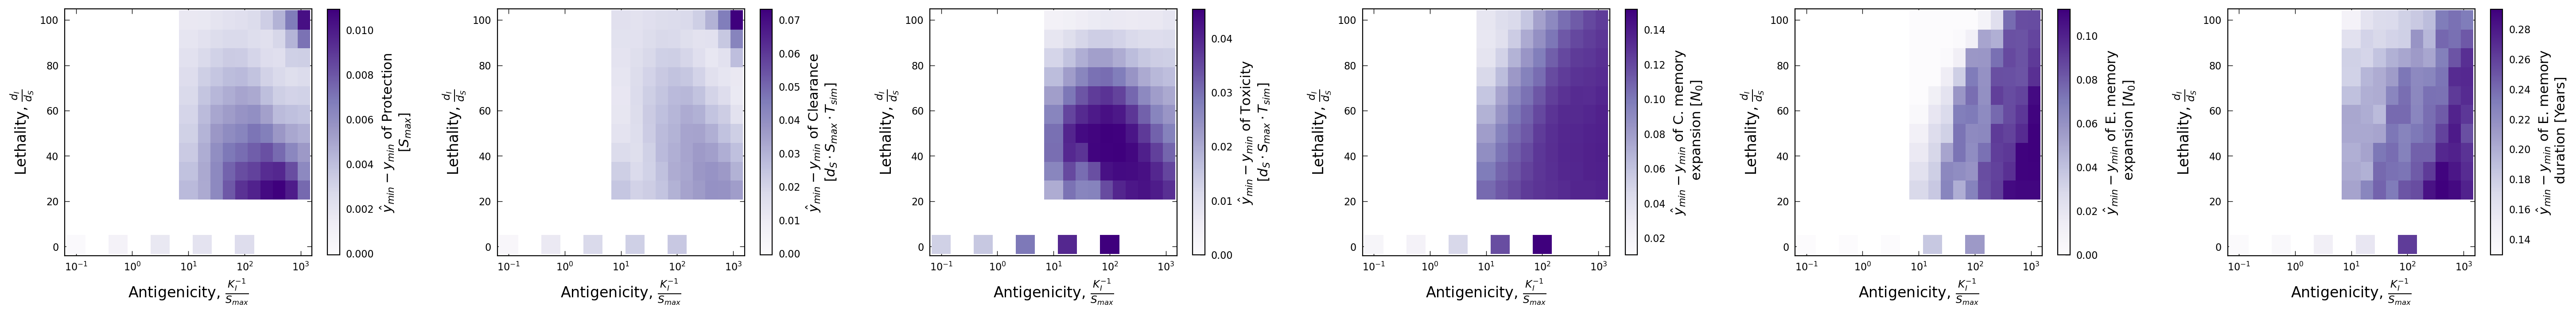

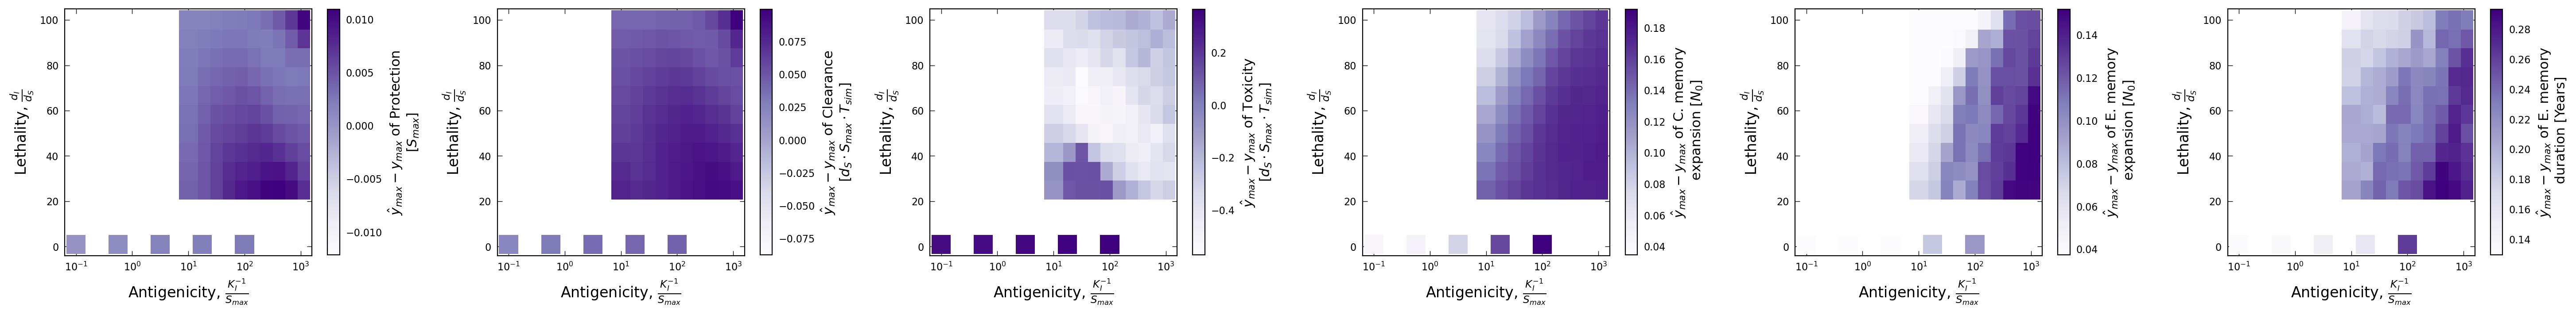

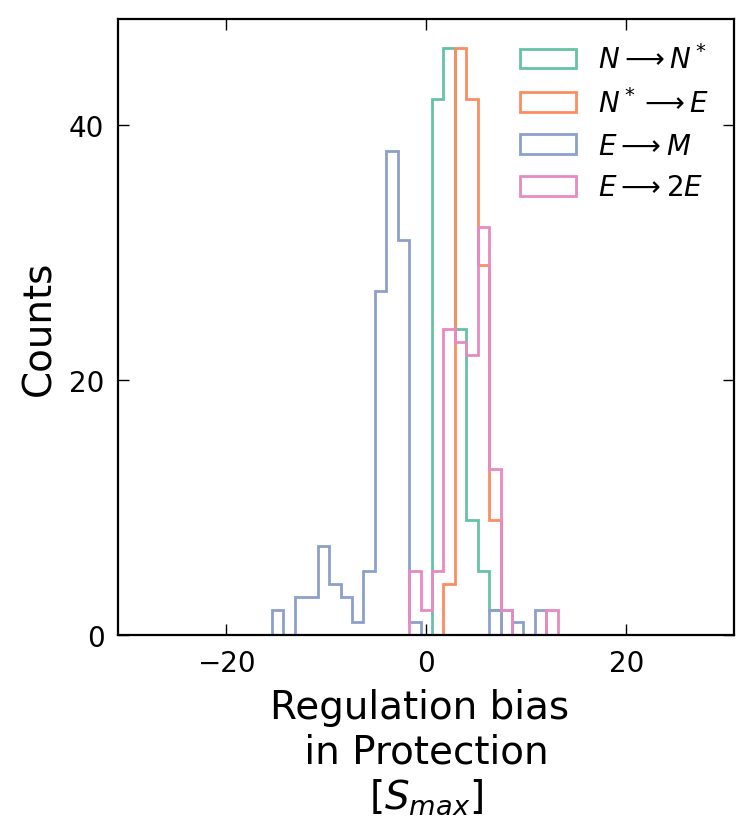

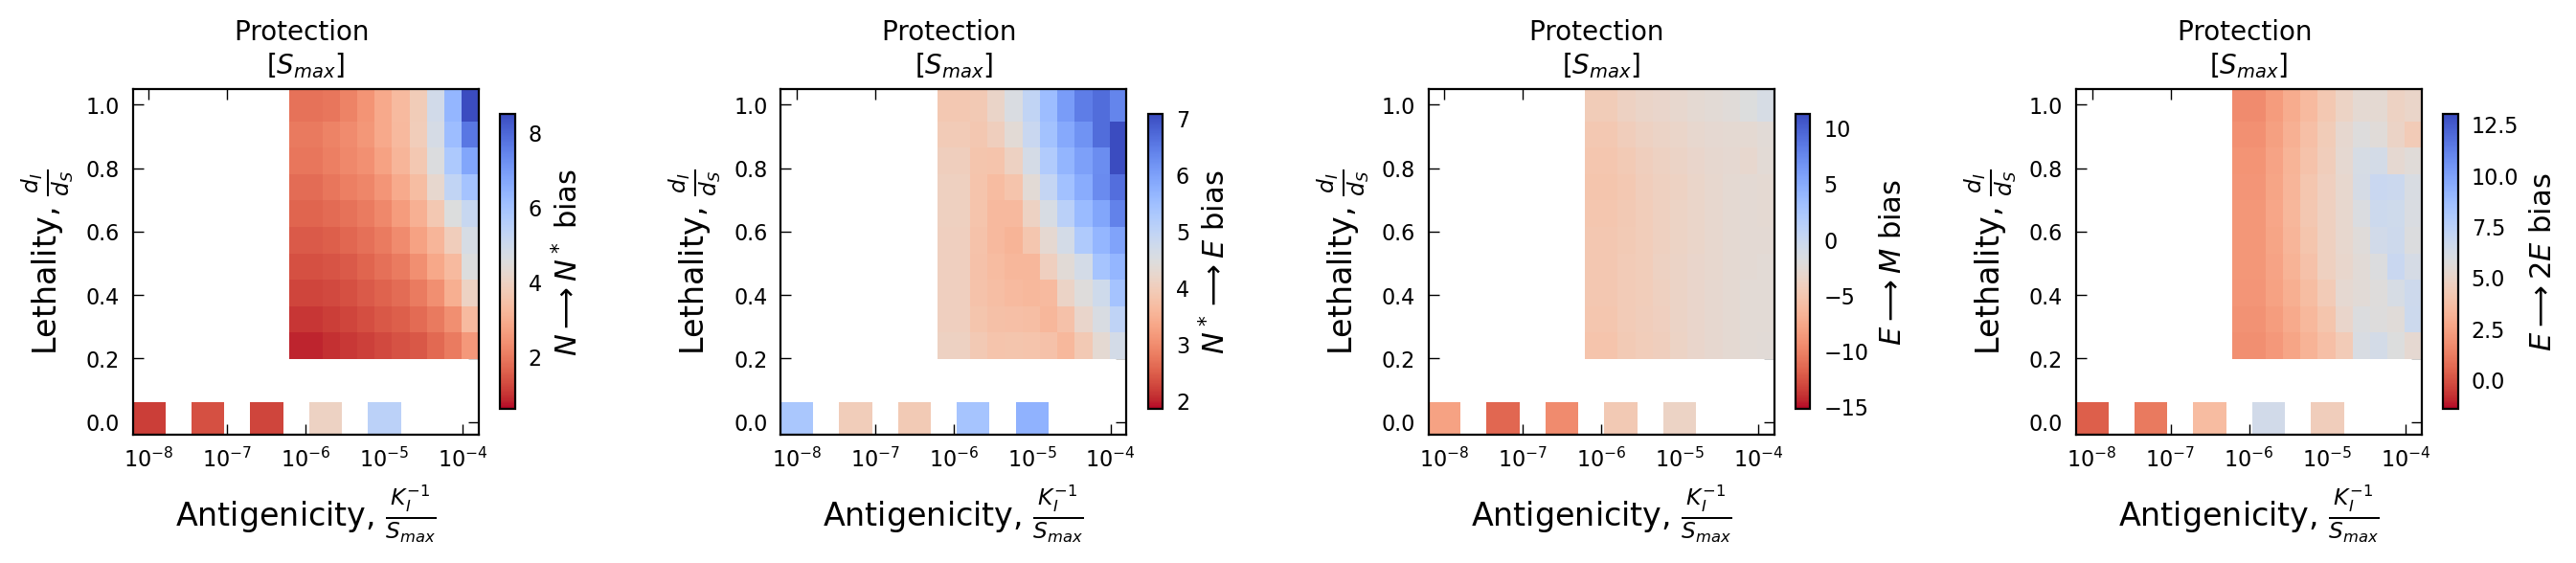

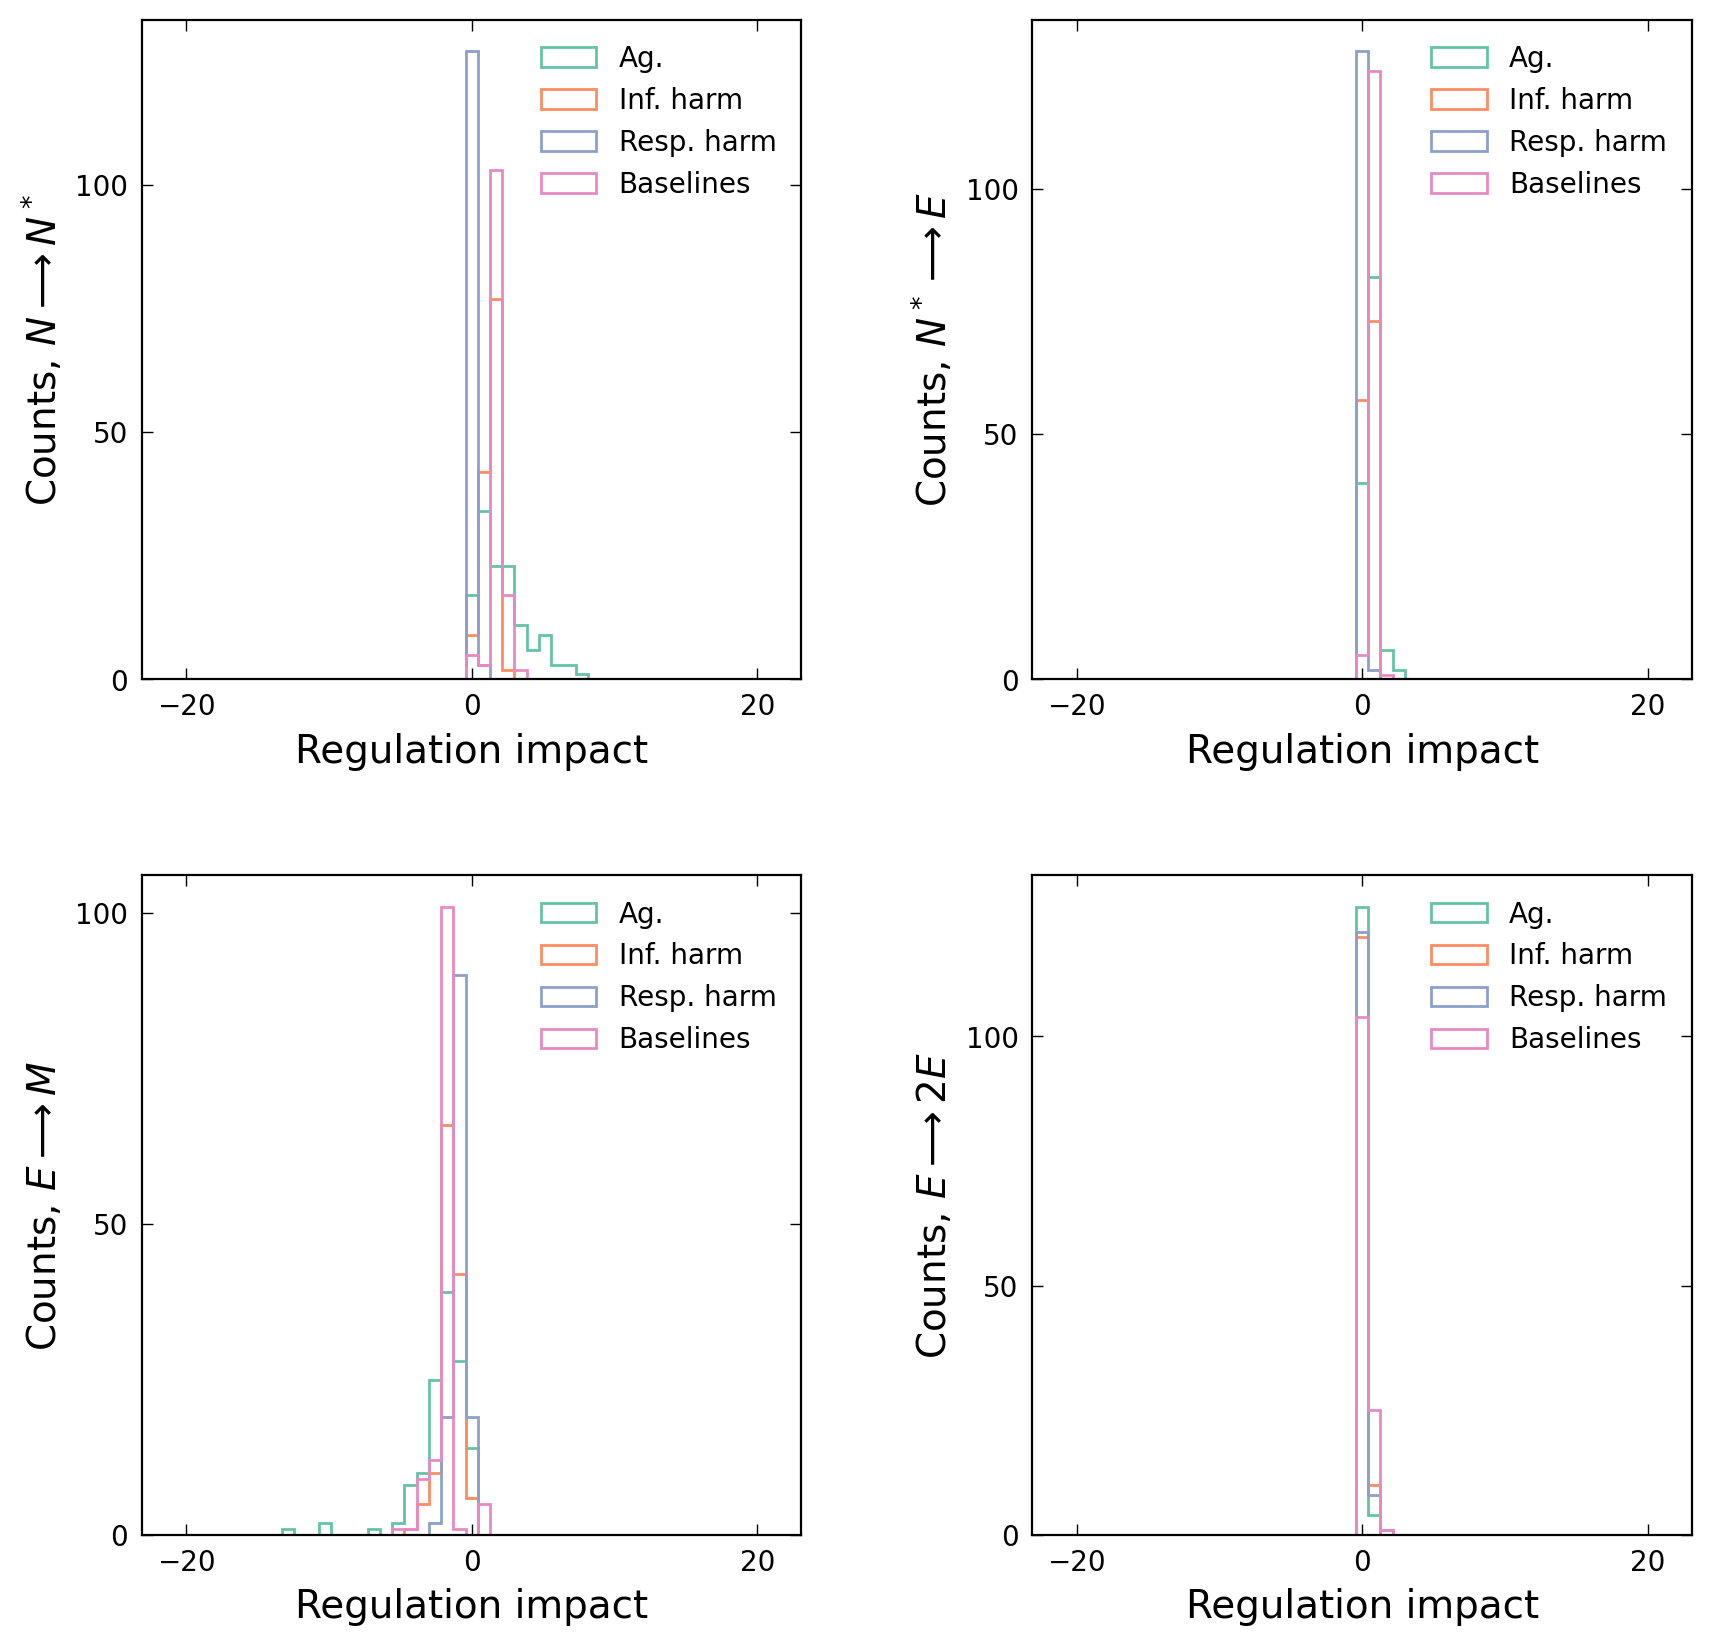

,y_range,y_min,psi_Na_I,psi_Na_HI,psi_Na_HE,L0_Na,psi_NE_I,psi_NE_HI,psi_NE_HE,L0_NE,psi_EM_I,psi_EM_HI,psi_EM_HE,L0_EM,psi_EE_I,psi_EE_HI,psi_EE_HE,L0_EE,intercept_Na,intercept_NE,intercept_EM,intercept_EE,sigma_y_max,sigma_y_min,sigma_psi_Na_I,sigma_psi_Na_HI,sigma_psi_Na_HE,sigma_L0_Na,sigma_psi_NE_I,sigma_psi_NE_HI,sigma_psi_NE_HE,sigma_L0_NE,sigma_psi_EM_I,sigma_psi_EM_HI,sigma_psi_EM_HE,sigma_L0_EM,sigma_psi_EE_I,sigma_psi_EE_HI,sigma_psi_EE_HE,sigma_L0_EE,sigma_intercept_Na,sigma_intercept_NE,sigma_intercept_EM,sigma_intercept_EE,d_I,K_I,b_I,K_H,N_0,S_0,I_0,mean_perf,max_perf,min_perf,median_perf,perf_index,rmse,y_std,harm_pI_noprotection,stim_pI,stim_pHI,stim_pHE,antigenicity_over_harm
0,0.000683,-0.006005,-0.001464,-0.010053,-0.001957,-0.059548,0.043177,0.006510,-0.004176,-0.048038,0.012226,0.005658,0.117515,1.276183,-0.032776,-0.010938,-0.037636,-0.148097,2.902149,3.054262,11.235107,3.752368,0.000102,0.000102,0.004904,0.004995,0.004905,0.006186,0.009129,0.005863,0.005806,0.008360,0.007116,0.007113,0.007404,0.121718,0.008024,0.007978,0.008033,0.005707,0.199123,0.250729,0.866344,0.174487,0.01,100000000.0,0.0,50000.0,100.000000,10000000.0,0.0,-0.005417,-0.005405,-0.006087,-0.005405,0.0,0.000063,0.000069,0.0,0.040966,0.312424,0.040534,NaN
6,0.001961,-0.007103,-0.000917,-0.005316,-0.001925,-0.059427,0.023396,-0.005437,-0.003246,-0.052097,0.010631,0.005065,0.155898,1.268068,-0.023810,-0.011862,-0.056206,-0.142001,2.845410,2.997189,10.939222,3.496584,0.000234,0.000234,0.005363,0.005391,0.005366,0.006737,0.007253,0.006321,0.006284,0.008706,0.006701,0.006699,0.007300,0.106382,0.007477,0.007452,0.007593,0.005363,0.182405,0.226640,0.754577,0.143040,0.01,100000000.0,0.0,50000.0,234.034732,10000000.0,0.0,-0.005447,-0.005405,-0.007365,-0.005405,0.0,0.000206,0.000228,0.0,0.040964,0.312424,0.061358,NaN
12,0.004901,-0.009613,-0.000771,-0.003390,-0.002656,-0.060660,0.017759,-0.006985,-0.003341,-0.054007,0.009657,0.005617,0.194771,0.983289,-0.020538,-0.011170,-0.080891,-0.133941,2.805032,2.989989,8.837587,3.343684,0.000517,0.000516,0.005405,0.005415,0.005411,0.006662,0.007038,0.006589,0.006523,0.008789,0.006388,0.006386,0.007390,0.037339,0.007020,0.006999,0.007339,0.005103,0.169803,0.215091,0.280141,0.128756,0.01,100000000.0,0.0,50000.0,547.722558,10000000.0,0.0,-0.005519,-0.005405,-0.010305,-0.005405,0.0,0.000534,0.000595,0.0,0.040959,0.312424,0.088222,NaN
18,0.011515,-0.015214,-0.000842,-0.003127,-0.003772,-0.061644,0.015901,-0.007807,-0.004384,-0.055060,0.009563,0.006979,0.233572,0.771869,-0.018608,-0.011283,-0.109080,-0.129234,2.766751,2.964502,7.313843,3.247608,0.001128,0.001125,0.005361,0.005368,0.005372,0.006513,0.006926,0.006623,0.006555,0.008673,0.006257,0.006256,0.007707,0.018257,0.006700,0.006683,0.007335,0.004895,0.161352,0.206467,0.157235,0.120880,0.01,100000000.0,0.0,50000.0,1281.861019,10000000.0,0.0,-0.005687,-0.005405,-0.016919,-0.005405,0.0,0.001279,0.001431,0.0,0.040948,0.312424,0.122296,NaN
24,0.025837,-0.027241,-0.000621,-0.002322,-0.004698,-0.061512,0.014955,-0.008371,-0.006046,-0.055456,0.009290,0.008437,0.269774,0.641406,-0.017277,-0.011279,-0.134705,-0.124015,2.722118,2.941890,6.378036,3.162070,0.002392,0.002385,0.005247,0.005251,0.005265,0.006384,0.006853,0.006617,0.006565,0.008595,0.006145,0.006145,0.008061,0.012206,0.006398,0.006383,0.007433,0.004698,0.156315,0.201545,0.121520,0.115430,0.01,100000000.0,0.0,50000.0,3000.000000,10000000.0,0.0,-0.006063,-0.005405,-0.031241,-0.005405,0.0,0.002899,0.003248,0.0,0.040923,0.312424,0.164333,NaN


,y_range,y_min,psi_Na_I,psi_Na_HI,psi_Na_HE,L0_Na,psi_NE_I,psi_NE_HI,psi_NE_HE,L0_NE,psi_EM_I,psi_EM_HI,psi_EM_HE,L0_EM,psi_EE_I,psi_EE_HI,psi_EE_HE,L0_EE,intercept_Na,intercept_NE,intercept_EM,intercept_EE,sigma_y_max,sigma_y_min,sigma_psi_Na_I,sigma_psi_Na_HI,sigma_psi_Na_HE,sigma_L0_Na,sigma_psi_NE_I,sigma_psi_NE_HI,sigma_psi_NE_HE,sigma_L0_NE,sigma_psi_EM_I,sigma_psi_EM_HI,sigma_psi_EM_HE,sigma_L0_EM,sigma_psi_EE_I,sigma_psi_EE_HI,sigma_psi_EE_HE,sigma_L0_EE,sigma_intercept_Na,sigma_intercept_NE,sigma_intercept_EM,sigma_intercept_EE,d_I,K_I,b_I,K_H,N_0,S_0,I_0,mean_perf,max_perf,min_perf,median_perf,perf_index,rmse,y_std,harm_pI_noprotection,stim_pI,stim_pHI,stim_pHE,antigenicity_over_harm
630,0.200891,-0.219524,5.545041,1.660110,0.168798,1.995153,2.565149,0.735440,0.057376,1.017118,-9.931828,-3.062879,-1.606615,-3.637053,0.235276,0.069301,0.040123,0.351931,3.113599,5.998746,-13.030333,5.348824,0.000151,2.827883e-05,0.026052,0.009670,0.005927,0.009000,0.010921,0.006259,0.005676,0.003317,0.067680,0.021686,0.012159,0.025067,0.020372,0.020286,0.020255,0.017925,0.015363,0.021982,0.087762,0.132065,0.01,1.000000e+05,0.1,50000.0,100.000000,10000000.0,1000000.0,-0.191452,-0.018937,-0.219827,-0.219720,0.0,0.013596,0.063035,2.651379,1.352578,0.582340,0.158916,-6.698971
636,0.202815,-0.218617,5.438547,1.626541,0.221339,1.961435,1.730622,0.469633,0.053529,0.601841,-12.701969,-3.917345,-2.495763,-4.722704,0.536125,0.094330,0.033645,0.555193,3.028437,3.914374,-15.226180,7.859035,0.000177,4.146872e-05,0.031337,0.011651,0.007233,0.010855,0.009313,0.005967,0.005615,0.002606,0.094849,0.030835,0.020896,0.034719,0.054760,0.051377,0.050782,0.107199,0.018285,0.017511,0.120337,0.767450,0.01,1.000000e+05,0.1,50000.0,234.034732,10000000.0,1000000.0,-0.183614,-0.017013,-0.219827,-0.219582,0.0,0.019788,0.073112,2.651379,1.306565,0.569679,0.191286,-6.698971
642,0.204672,-0.218517,6.154857,1.866001,0.253953,2.200565,2.167597,0.601838,0.074144,0.738130,-10.291583,-3.036648,-2.072950,-3.850860,0.347999,0.112617,0.029231,0.957904,3.762093,5.336636,-11.369838,12.054839,0.000149,3.979079e-05,0.037347,0.012949,0.006681,0.012969,0.012572,0.006581,0.005774,0.004109,0.051517,0.017117,0.013039,0.018929,0.211842,0.210472,0.207742,1.657811,0.024221,0.028850,0.062485,11.658353,0.01,1.000000e+05,0.1,50000.0,547.722558,10000000.0,1000000.0,-0.178987,-0.015156,-0.219827,-0.219269,0.0,0.018915,0.078168,2.651379,1.272423,0.562193,0.233255,-6.698971
648,0.206499,-0.218147,6.960482,2.153403,0.292483,2.464657,2.062883,0.623244,0.081214,0.760016,-6.875791,-2.085138,-1.470674,-2.630462,0.243838,0.052971,-0.031495,0.951545,4.664599,5.709882,-6.816120,12.991619,0.000141,3.962737e-05,0.046263,0.015584,0.006829,0.016019,0.012442,0.006634,0.005674,0.004622,0.028750,0.010355,0.008132,0.010766,0.589889,0.591954,0.591320,4.315818,0.032632,0.032646,0.032020,30.348961,0.01,1.000000e+05,0.1,50000.0,1281.861019,10000000.0,1000000.0,-0.176279,-0.013329,-0.219827,-0.218535,0.0,0.018649,0.079849,2.651379,1.253496,0.559009,0.285698,-6.698971
654,0.208233,-0.217364,7.662277,2.391910,0.333938,2.697977,1.823028,0.541180,0.066364,0.733154,-4.744115,-1.424056,-1.144621,-1.810433,0.198739,0.036956,-0.319661,0.037429,5.452390,5.724557,-3.697574,4.529097,0.000855,4.111303e-05,0.053032,0.017652,0.007044,0.018333,0.010952,0.006271,0.005547,0.004641,0.016308,0.006482,0.005829,0.006001,0.061560,0.037429,0.094286,0.013969,0.039297,0.032915,0.014352,0.392605,0.01,1.000000e+05,0.1,50000.0,3000.000000,10000000.0,1000000.0,-0.173306,-0.011577,-0.219827,-0.216818,0.0,0.018450,0.079927,2.651379,1.238411,0.555574,0.341706,-6.698971
660,0.200379,-0.219576,2.341164,1.447811,0.169683,1.724760,1.460744,0.916384,0.098810,1.191517,-4.388117,-2.850487,-1.486538,-3.419581,0.094212,0.065242,0.031029,0.334908,2.276364,6.570234,-12.949089,4.631738,0.000140,2.359729e-05,0.009219,0.006906,0.004929,0.005717,0.006341,0.005631,0.004895,0.003187,0.018701,0.012776,0.007449,0.014361,0.011581,0.011576,0.011570,0.008925,0.007674,

In [6]:
%run ./fit-observables.ipynb